# Kaggle: product category prediction

This notebook trains a text-based multiclass classifier for `production-ml-spring-2026` and writes `submission.csv` in the required format: `ID,category_ind`.

The solution uses product text fields plus tokenized URL/image URL text. Images are not downloaded; their URLs often contain useful vendor/product path tokens, while downloading images would make the notebook much slower.


In [1]:
import os
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
import joblib

from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from scipy.sparse import hstack
from catboost import CatBoostClassifier

from tqdm.auto import tqdm

import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn
import os
import shutil

warnings.filterwarnings('ignore')

EXPERIMENT_NAME = "[MLOps] ECOM-product-classifiers"
PROJECT_NAME = 'production-ml-spring-2026'
BASE_DIR = Path('/Users/nsdemidov/Projects/education_projects/VK-EDUCATION/mlops/project')
DATA_DIR = BASE_DIR / 'data'
SUBMISSION_PATH = BASE_DIR / 'submission.csv'



RANDOM_STATE = 42
VALID_SIZE = 0.20

os.environ['KAGGLE_USERNAME'] = 'kikach'
os.environ['KAGGLE_KEY'] = '9669fcb8655912cbae9a3511008fc160'



## Load data

If data is already in `data/`, downloading is skipped. If you need to download again, set Kaggle credentials and uncomment the download cell below.


In [2]:
DATA_DIR.mkdir(parents=True, exist_ok=True)

!kaggle competitions download -c {PROJECT_NAME} -p {DATA_DIR} --force
!unzip -o {DATA_DIR / (PROJECT_NAME + ".zip")} -d {DATA_DIR}


train = pd.read_parquet(DATA_DIR / 'train.parquet.snappy')
test = pd.read_parquet(DATA_DIR / 'test.parquet.snappy')
tree = pd.read_csv(DATA_DIR / 'tree.csv')

100%|██████████████████████████████████████| 13.8M/13.8M [00:01<00:00, 8.78MB/s]

Archive:  /Users/nsdemidov/Projects/education_projects/VK-EDUCATION/mlops/project/data/production-ml-spring-2026.zip
  inflating: /Users/nsdemidov/Projects/education_projects/VK-EDUCATION/mlops/project/data/test.parquet.snappy  
  inflating: /Users/nsdemidov/Projects/education_projects/VK-EDUCATION/mlops/project/data/train.parquet.snappy  
  inflating: /Users/nsdemidov/Projects/education_projects/VK-EDUCATION/mlops/project/data/tree.csv  


## EDA

### общая информация о классах

In [3]:
label_counts = train['category_ind'].value_counts().sort_index()

train_labels = set(train['category_ind'])
tree_labels = set(tree['category_ind'])

missing_labels = sorted(tree_labels - train_labels)
extra_labels = sorted(train_labels - tree_labels)

print('Кол-во классов в трейне:', train['category_ind'].nunique())
print('Кол-во классов:', tree['category_ind'].nunique())
print('Признаки :', test.columns.tolist())
display(test.head(3))
display(tree.head(3))


Кол-во классов в трейне: 207
Кол-во классов: 223
Признаки : ['name', 'description', 'model', 'type_prefix', 'vendor', 'url', 'image_url']


,name,description,model,type_prefix,vendor,url,image_url
0,Мягкая Кровать Орматек Атлантико (Ткань: Велюр...,Роскошная кровать изогнутой формы из экокожи к...,Кровать Атлантико,Кровать,Орматек,https://ormatek.com/catalog/krovati/product/kr...,http://d.mradx.net//ecomimg/cc0/43/61850d7af82...
1,Одеяло 3-в-1 Proson,,,,"ООО ""Бэст-Мебель""",https://tver.bestmebelshop.ru/catalog/tekstil/...,http://d.mradx.net//ecomimg/bdc/ad/020b20d7418...
2,L`ONDE Парфюмерная вода для женщин 50 мл,,,,Dilis,https://groupprice.ru/products/2100905-l-onde-...,http://d.mradx.net//ecomimg/289/19/b439af2bbd4...


,category,category_ind
0,Бытовая техника -> Встраиваемая техника,0
1,Бытовая техника -> Климатическая техника,1
2,Бытовая техника -> Крупная техника для кухни,2


### статистики распределения товаров по классам

In [4]:
print('Статистики распределения классов')
print(
    int(label_counts.min()),
    float(label_counts.median()),
    round(float(label_counts.mean()), 2),
    int(label_counts.max())
)

display(label_counts.describe().to_frame('count_stats'))


Статистики распределения классов
1 25.0 538.19 31563


,count_stats
count,207.000000
mean,538.188406
std,2792.198804
min,1.000000
25%,10.000000
50%,25.000000
75%,78.500000
max,31563.000000


### Топ классов по частоте:



In [5]:
TOP_N = 15

label_stats = (
    label_counts
    .rename('count')
    .reset_index()
    .rename(columns={'index': 'category_ind'})
    .merge(
        tree[['category_ind', 'category']],
        on='category_ind',
        how='left'
    )
)

print(f'{TOP_N} самых частых классов:')
display(
    label_stats
    .sort_values('count', ascending=False)
    .head(TOP_N)
    [['category_ind', 'category', 'count']]
)

print(f'{TOP_N} самых редких классов:')
display(
    label_stats
    .sort_values('count', ascending=True)
    .head(TOP_N)
    [['category_ind', 'category', 'count']]
)


15 самых частых классов:


,category_ind,category,count
33,34,Красота и уход -> Парфюмерия,31563
47,48,Мебель -> Офисная мебель,21760
41,42,Мебель -> Кровати и матрасы,9284
66,71,"Одежда, обувь и аксессуары -> Женская одежда -...",4616
159,173,Товары для дома -> Текстиль для дома,3953
36,37,Красота и уход -> Уход за волосами,3801
43,44,Мебель -> Мебель для ванной,3692
76,81,"Одежда, обувь и аксессуары -> Женская одежда -...",3137
67,72,"Одежда, обувь и аксессуары -> Женская одежда -...",3055
205,221,Ювелирные изделия и часы -> Серьги,2368


15 самых редких классов:


,category_ind,category,count
83,88,"Одежда, обувь и аксессуары -> Женская одежда -...",1
91,97,"Одежда, обувь и аксессуары -> Мужская обувь ->...",1
92,98,"Одежда, обувь и аксессуары -> Мужская обувь ->...",1
121,130,Сад и огород -> Садовая техника,1
123,132,"Сад и огород -> Семена, удобрения и уход за ра...",1
22,23,Зоотовары -> Прочие товары и инструменты для ж...,1
172,186,Транспорт -> Водный транспорт,1
49,52,Недвижимость -> Продажа жилой недвижимости,2
103,110,"Одежда, обувь и аксессуары -> Мужская одежда -...",2
176,192,Хобби и увлечения -> Антиквариат и коллекциони...,2


### график распределения частотности классов (чтобы проверить дизбаланс)

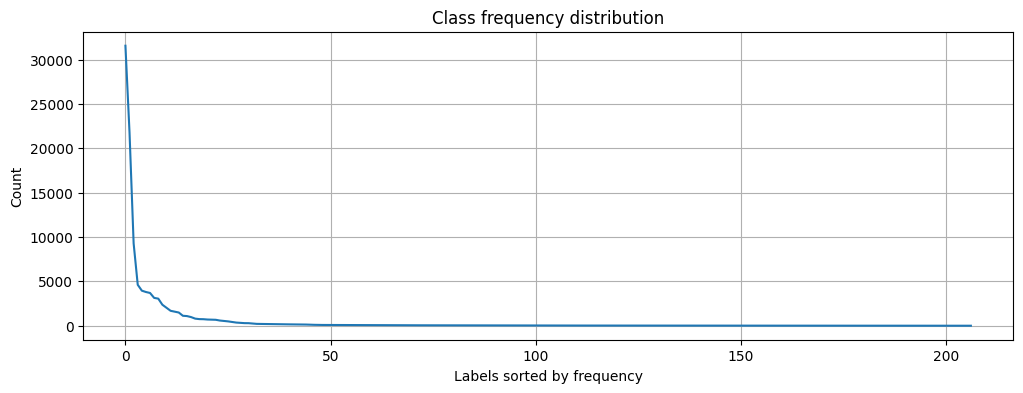

In [6]:
plt.figure(figsize=(12, 4))
label_counts.sort_values(ascending=False).reset_index(drop=True).plot()
plt.title('Class frequency distribution')
plt.xlabel('Labels sorted by frequency')
plt.ylabel('Count')
plt.grid(True)
plt.show()


## Feature engineering

All fields are converted to one text string. Important short fields are repeated to increase their weight for TF-IDF:

- `name`, `type_prefix` — strongest fields;
- `model`, `vendor` — useful product/vendor hints;
- `description` — long text;
- `url`, `image_url` — tokenized path/domain hints.


In [7]:
def clean_url_series(s: pd.Series) -> pd.Series:
    s = s.fillna('').astype(str).str.lower()
    s = s.str.replace(r'https?://', ' ', regex=True)
    s = s.str.replace(r'www\.', ' ', regex=True)
    s = s.str.replace(r'utm_[a-z_]+=[^&\s]+', ' ', regex=True)
    s = s.str.replace(r'[^0-9a-zа-яё]+', ' ', regex=True)
    return s


def normalize_text_series(s: pd.Series) -> pd.Series:
    s = s.fillna('').astype(str).str.lower()
    s = s.str.replace('ё', 'е', regex=False)
    s = s.str.replace(r'[^0-9a-zа-яе]+', ' ', regex=True)
    s = s.str.replace(r'\s+', ' ', regex=True).str.strip()
    return s


def make_text(df: pd.DataFrame) -> pd.Series:
    name = normalize_text_series(df['name'])
    desc = normalize_text_series(df['description'])
    model = normalize_text_series(df['model'])
    type_prefix = normalize_text_series(df['type_prefix'])
    vendor = normalize_text_series(df['vendor'])
    url = clean_url_series(df['url'])
    image_url = clean_url_series(df['image_url'])

    text = (
        (' name ' + name) * 3 +
        (' type ' + type_prefix) * 3 +
        (' model ' + model) * 2 +
        (' vendor ' + vendor) * 2 +
        ' desc ' + desc +
        ' url ' + url +
        ' image ' + image_url
    )
    return text.str.replace(r'\s+', ' ', regex=True).str.strip()


def make_ids_for_submission(test_df: pd.DataFrame) -> np.ndarray:
    for col in ['ID', 'id']:
        if col in test_df.columns:
            return test_df[col].to_numpy()
    return np.arange(0, len(test_df))


def prepare_data(train_df, test_df=None, valid_size=None, random_state=42):
    X_train_text = make_text(train_df)
    X_test_text = make_text(test_df) if test_df is not None else None
    y_full = train_df['category_ind'].astype(int).to_numpy()
    
    result = {
        'X_train_text': X_train_text,
        'X_test_text': X_test_text,
        'y_full': y_full,
    }
    
    if valid_size is not None:
        counts = pd.Series(y_full).value_counts()
        can_stratify = np.array([counts[label] >= 2 for label in y_full])
        idx_common = np.where(can_stratify)[0]
        idx_rare = np.where(~can_stratify)[0]

        train_common_idx, valid_idx = train_test_split(
            idx_common,
            test_size=valid_size,
            random_state=random_state,
            stratify=y_full[idx_common],
        )
        train_idx = np.concatenate([train_common_idx, idx_rare])
        
        print(f'Train rows: {len(train_idx):,}; Valid rows: {len(valid_idx):,}; Rare-only-train rows: {len(idx_rare):,}')
        print(f'Valid labels: {len(np.unique(y_full[valid_idx]))}; All train labels: {len(np.unique(y_full))}')
        
        result['train_idx'] = train_idx
        result['valid_idx'] = valid_idx
    
    return result


def prepare_tfidf_features(X_train_text, X_valid_text=None, X_test_text=None,
                          word_max_features=180000, char_max_features=120000):
    result = {}
    
    word_vectorizer = TfidfVectorizer(
        analyzer='word', ngram_range=(1, 2), min_df=2, max_df=0.98,
        sublinear_tf=True, strip_accents=None, max_features=word_max_features, dtype=np.float32,
    )
    X_train_word = word_vectorizer.fit_transform(X_train_text)
    result['word_vectorizer'] = word_vectorizer
    result['X_train_word'] = X_train_word
    
    if X_valid_text is not None:
        result['X_valid_word'] = word_vectorizer.transform(X_valid_text)
    if X_test_text is not None:
        result['X_test_word'] = word_vectorizer.transform(X_test_text)
    
    char_vectorizer = TfidfVectorizer(
        analyzer='char_wb', ngram_range=(3, 5), min_df=3,
        sublinear_tf=True, max_features=char_max_features, dtype=np.float32,
    )
    X_train_char = char_vectorizer.fit_transform(X_train_text)
    result['char_vectorizer'] = char_vectorizer
    result['X_train_char'] = X_train_char
    
    if X_valid_text is not None:
        result['X_valid_char'] = char_vectorizer.transform(X_valid_text)
    if X_test_text is not None:
        result['X_test_char'] = char_vectorizer.transform(X_test_text)
    
    result['X_train'] = hstack([X_train_word, X_train_char], format='csr', dtype=np.float32)
    print(f'Train feature matrix: {result["X_train"].shape}')
    
    if X_valid_text is not None:
        result['X_valid'] = hstack([result['X_valid_word'], result['X_valid_char']], format='csr', dtype=np.float32)
    if X_test_text is not None:
        result['X_test'] = hstack([result['X_test_word'], result['X_test_char']], format='csr', dtype=np.float32)
        print(f'Test feature matrix: {result["X_test"].shape}')
    
    return result


def fit_and_eval_model(model, model_name, X_train, y_train, X_valid, y_valid):
    print(f"=== Начало Обучения {model_name} ===")
    start_time = time.time()
    
    model.fit(X_train, y_train)
    valid_pred = model.predict(X_valid)
    train_time = time.time() - start_time
    
    macro_f1 = f1_score(y_valid, valid_pred, average='macro')
    weighted_f1 = f1_score(y_valid, valid_pred, average='weighted')
    
    print(f"Время обучения: {train_time:.1f} сек")
    print(f"=== Конец Обучения {model_name} ===")

    metric_result = {
        'model_name': model_name, 'model': model,
        'macro_f1': macro_f1, 'weighted_f1': weighted_f1,
        'train_time': train_time, 'predictions': valid_pred
    }

    return model, metric_result


def get_model_config(model_name, models_config):
    for model_config in models_config:
        if model_config['name'] == model_name:
            return model_config["model"]
    raise ValueError(f'Модель {model_name} не найдена')


def make_predict(model, X_test, test_df, output_path):
    test_pred = model.predict(X_test).astype(int)
    
    submission = pd.DataFrame({
        'ID': make_ids_for_submission(test_df),
        'category_ind': test_pred,
    })
    
    try:
        submission.to_csv(output_path, index=False)
        print(f'Предсказание успешно сделано в {output_path}')
    except Exception as e:
        print(f'Что-то пошло не так;( {e}')
    
    return test_pred

## Local validation

`LinearSVC` is a strong and fast baseline for sparse text features. The validation split is stratified for labels with at least 2 objects; labels with only one object remain in the training part.

The progress bar is stage-based because `TfidfVectorizer` and `LinearSVC` do not expose internal iteration progress.


## Train on all labeled data and create submission

This cell retrains the same vectorizers/model on the full training set and writes `submission.csv`.


In [8]:
models_config = [
    {
        'name': 'SGDClassifier',
        'model': SGDClassifier(
            loss='log_loss', penalty='l2', alpha=0.0001,
            max_iter=10, tol=1e-3, class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1
        )
    },
    # {
    #     'name': 'CatBoost',
    #     'model': CatBoostClassifier(
    #         iterations=10, learning_rate=0.1, depth=6,
    #         loss_function='MultiClass', random_state=RANDOM_STATE,
    #         thread_count=-1, verbose=False, auto_class_weights='Balanced'
    #     )
    # },
    # {
    #     'name': 'RandomForest',
    #     'model': RandomForestClassifier(
    #         n_estimators=10, class_weight='balanced',
    #         random_state=RANDOM_STATE, n_jobs=-1
    #     )
    # },
    # {
    #     'name': 'MLPClassifier',
    #     'model': MLPClassifier(
    #         hidden_layer_sizes=(64, 64), activation='relu', solver='adam',
    #         alpha=0.001, batch_size=64, learning_rate='adaptive',
    #         learning_rate_init=0.001, max_iter=2,
    #         early_stopping=True, n_iter_no_change=10, random_state=RANDOM_STATE
    #     )
    # }
]

data = prepare_data(train, valid_size=VALID_SIZE, random_state=RANDOM_STATE)
features = prepare_tfidf_features(
    data['X_train_text'],
    X_valid_text=data['X_train_text'].iloc[data['valid_idx']],
    X_test_text=None
)

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment(EXPERIMENT_NAME + "|555")


results = []
for model_config in models_config:
    with mlflow.start_run(run_name=model_config['name']):
        mlflow.log_params(model_config['model'].get_params())
        
        best_model, result = fit_and_eval_model(
            model_config['model'], model_config['name'],
            features['X_train'][data['train_idx']], data['y_full'][data['train_idx']],
            features['X_valid'], data['y_full'][data['valid_idx']]
        )
        mlflow.log_metrics({
            "macro_f1": result['macro_f1'],
            "weighted_f1": result['weighted_f1'],
            "train_time": result['train_time']
        })
        mlflow.sklearn.log_model(best_model, name="model")
        
        results.append(result)

print("="*20 + "СРАВНЕНИЕ МОДЕЛЕЙ:" + "="*20)
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('macro_f1', ascending=False)
print(results_df[['model_name', 'macro_f1', 'weighted_f1', 'train_time']])

best_model_result = results_df.iloc[0]
macro_f1 = best_model_result['macro_f1']

Train rows: 89,125; Valid rows: 22,280; Rare-only-train rows: 7
Valid labels: 193; All train labels: 207
Train feature matrix: (111405, 300000)
=== Начало Обучения SGDClassifier ===


2026/05/12 20:39:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Время обучения: 13.1 сек
=== Конец Обучения SGDClassifier ===
====================СРАВНЕНИЕ МОДЕЛЕЙ:====================
      model_name  macro_f1  weighted_f1  train_time
0  SGDClassifier   0.56023     0.961479    13.09809


## Submit to Kaggle

Run this after checking `submission.csv`.


In [9]:
data_full = prepare_data(train, test_df=test, valid_size=None)
features_full = prepare_tfidf_features(
    data_full['X_train_text'],
    X_test_text=data_full['X_test_text']
)

X_train = features_full['X_train']

best_model = get_model_config(best_model_result['model_name'], models_config)
best_model.fit(X_train, data_full['y_full'])

Train feature matrix: (111405, 300000)
Test feature matrix: (37136, 300000)


,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",10
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1


## Делаем предсказание

In [10]:
_ = make_predict(best_model, features_full['X_test'], test, SUBMISSION_PATH)


Предсказание успешно сделано в /Users/nsdemidov/Projects/education_projects/VK-EDUCATION/mlops/project/submission.csv
